This notebook is intended to be used for initial observations of episodic pivot statistics. Episodic pivots are here defined as a technical event where a stock gaps >= 8% overnight and closes above the 20DMA. The stock remains an episodic pivot until it closes beneath the 20DMA.

In [1]:
%run "..\scripts\load_daily_variables.py"

Loading Variables: 100%|██████████| 27/27 [01:47<00:00,  3.98s/it]


In [2]:
ep = Episodic_Pivots(symbols)
ep.load_all()

Loading Episodic Pivots: 100%|██████████| 3063/3063 [38:02<00:00,  1.34it/s]  


# Descriptive Statistics

## EP Count

Current EP Count: 95.0
Importing Price Data: 100%|██████████| 1/1 [00:01<00:00,  1.19s/it]


<Axes: xlabel='Date'>

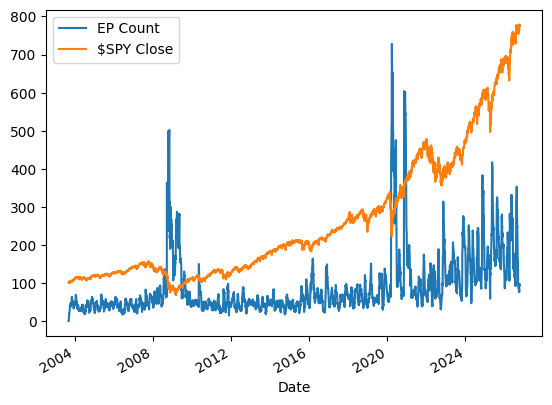

In [3]:
print(f'Current EP Count: {ep.ep_count(include_spy=False, plot=False).iloc[-1]}')
ep.ep_count()

## Drawdown Statistics

- Iteration, Calculation, and Cumulative Display
- Drawdown results displays the drawdown with the respective symbol and date.

In [4]:
# Flatten the complete nested dictionary into one row per episodic pivot.
drawdown_results = pd.DataFrame(
    [
        {
            "symbol": symbol,
            "ep_date": pd.to_datetime(ep_date),
            "drawdown_pct": drawdown,
        }
        for symbol, pivots in ep.drawdown_dict.items()
        for ep_date, drawdown in pivots.items()
    ]
)

# Ensure statistics only use valid numeric results.
drawdown_results["drawdown_pct"] = pd.to_numeric(
    drawdown_results["drawdown_pct"], errors="coerce"
)
drawdown_results.replace([np.inf, -np.inf], np.nan, inplace=True)

# Overall descriptive statistics.
drawdown_statistics = drawdown_results["drawdown_pct"].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).to_frame(name="drawdown_pct")

drawdown_statistics.loc["missing"] = drawdown_results["drawdown_pct"].isna().sum()
drawdown_statistics.loc["skew"] = drawdown_results["drawdown_pct"].skew()
drawdown_statistics.loc["kurtosis"] = drawdown_results["drawdown_pct"].kurt()

display(drawdown_results)

,symbol,ep_date,drawdown_pct
0,META,2024-08-01,-13.474088
1,META,2023-04-27,-4.185252
2,META,2023-02-02,-8.572363
3,META,2025-07-31,-3.855779
4,META,2022-06-09,-20.604282
...,...,...,...
38416,X,2020-06-16,-23.025690
38417,X,2020-03-13,-17.304189
38418,X,2021-10-29,-7.103409
38419,X,2023-08-14,-1.058201


In [5]:
display(drawdown_statistics)

,drawdown_pct
count,38421.000000
mean,-15.373678
std,14.777562
min,-100.000000
1%,-71.767236
5%,-46.099291
10%,-34.415584
25%,-19.985452
50%,-11.015326
75%,-5.581395


- By Symbol

In [6]:
drawdown_statistics_by_symbol = (
    drawdown_results
    .groupby("symbol")["drawdown_pct"]
    .describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90])
    .sort_values("count", ascending=False)
)

display(drawdown_statistics_by_symbol)

,count,mean,std,min,10%,25%,50%,75%,90%,max
symbol,,,,,,,,,,
SHIP,150.0,-24.955138,17.505784,-86.335404,-48.856000,-32.233187,-19.694444,-12.997786,-8.497368,0.000000
CNR,146.0,-21.226590,16.986120,-91.775701,-45.818815,-27.475369,-16.607143,-10.562771,-5.439815,0.000000
IVA,139.0,-25.180741,18.989980,-76.000000,-54.196404,-38.852862,-18.511662,-10.378037,-7.613971,0.000000
LPTH,124.0,-19.871135,10.909331,-52.662722,-32.745918,-27.398010,-17.887361,-11.413063,-7.606738,0.000000
AEHR,120.0,-14.219507,9.085851,-55.555556,-26.642960,-20.374976,-12.548201,-7.524221,-3.687943,0.000000
...,...,...,...,...,...,...,...,...,...,...
HON,1.0,-5.602743,NaN,-5.602743,-5.602743,-5.602743,-5.602743,-5.602743,-5.602743,-5.602743
XIFR,1.0,-4.460581,NaN,-4.460581,-4.460581,-4.460581,-4.460581,-4.460581,-4.460581,-4.460581
ABT,1.0,-9.030544,NaN,-9.030544,-9.030544,-9.030544,-9.030544,-9.030544,-9.030544,-9.030544


## Returns Statistics

- Iteration, Calculation, and Cumulative Display
- Returns results displays the returns with the respective symbol and date.

In [7]:
# Flatten the complete nested dictionary into one row per episodic pivot.
returns_results = pd.DataFrame(
    [
        {
            "symbol": symbol,
            "ep_date": pd.to_datetime(ep_date),
            "return_pct": ep_return,
        }
        for symbol, pivots in ep.returns_dict.items()
        for ep_date, ep_return in pivots.items()
    ]
)

# Ensure statistics only use valid numeric results.
returns_results["return_pct"] = pd.to_numeric(
    returns_results["return_pct"], errors="coerce"
)
returns_results.replace([np.inf, -np.inf], np.nan, inplace=True)

# Overall descriptive statistics.
returns_statistics = returns_results["return_pct"].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).to_frame(name="return_pct")

returns_statistics.loc["missing"] = returns_results["return_pct"].isna().sum()
returns_statistics.loc["skew"] = returns_results["return_pct"].skew()
returns_statistics.loc["kurtosis"] = returns_results["return_pct"].kurt()

display(returns_results)

,symbol,ep_date,return_pct
0,META,2024-08-01,-8.689060
1,META,2023-04-27,22.664555
2,META,2023-02-02,-7.083651
3,META,2025-07-31,-3.059856
4,META,2022-06-09,-16.162240
...,...,...,...
38416,X,2020-06-16,-22.454805
38417,X,2020-03-13,31.693989
38418,X,2021-10-29,-6.684441
38419,X,2023-08-14,7.830688


In [8]:
display(returns_statistics)

,return_pct
count,3.842100e+04
mean,5.288260e+03
std,4.656676e+05
min,-1.000000e+02
1%,-5.575175e+01
5%,-3.187500e+01
10%,-2.265625e+01
25%,-1.234043e+01
50%,-4.226619e+00
75%,7.044025e+00


- By Symbol

In [9]:
returns_statistics_by_symbol = (
    returns_results
    .groupby("symbol")["return_pct"]
    .describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90])
    .sort_values("count", ascending=False)
)

display(returns_statistics_by_symbol)

,count,mean,std,min,10%,25%,50%,75%,90%,max
symbol,,,,,,,,,,
SHIP,150.0,-13.379054,23.144291,-85.714286,-42.881988,-22.165976,-10.408333,-4.370370,8.084236,65.632375
CNR,146.0,-2.488264,72.906473,-91.775701,-33.180150,-19.343644,-10.731150,0.575571,12.733063,797.959184
IVA,139.0,59.000661,797.076111,-60.000000,-31.854545,-19.923986,-8.031359,0.000000,20.000000,9385.829960
LPTH,124.0,-5.602524,24.358765,-46.745562,-26.580529,-20.042017,-9.752741,-0.917785,18.402778,116.176471
AEHR,120.0,2.438152,32.292642,-26.829268,-20.834943,-14.933151,-6.558747,4.979230,34.389308,190.518519
...,...,...,...,...,...,...,...,...,...,...
HON,1.0,1.483639,NaN,1.483639,1.483639,1.483639,1.483639,1.483639,1.483639,1.483639
XIFR,1.0,-2.385892,NaN,-2.385892,-2.385892,-2.385892,-2.385892,-2.385892,-2.385892,-2.385892
ABT,1.0,8.475190,NaN,8.475190,8.475190,8.475190,8.475190,8.475190,8.475190,8.475190


## Max Returns Statistics

- Iteration, Calculation, and Cumulative Display
- max_returns results displays the max returns with the respective symbol and date.

In [10]:
# Flatten the complete nested dictionary into one row per episodic pivot.
max_returns_results = pd.DataFrame(
    [
        {
            "symbol": symbol,
            "ep_date": pd.to_datetime(ep_date),
            "max_return_pct": max_return,
        }
        for symbol, pivots in ep.max_return_dict.items()
        for ep_date, max_return in pivots.items()
    ]
)

# Ensure statistics only use valid numeric results.
max_returns_results["max_return_pct"] = pd.to_numeric(
    max_returns_results["max_return_pct"], errors="coerce"
)
max_returns_results.replace([np.inf, -np.inf], np.nan, inplace=True)

# Overall descriptive statistics.
max_returns_statistics = max_returns_results["max_return_pct"].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).to_frame(name="max_return_pct")

max_returns_statistics.loc["missing"] = max_returns_results["max_return_pct"].isna().sum()
max_returns_statistics.loc["skew"] = max_returns_results["max_return_pct"].skew()
max_returns_statistics.loc["kurtosis"] = max_returns_results["max_return_pct"].kurt()

display(max_returns_results)

,symbol,ep_date,max_return_pct
0,META,2024-08-01,1.184434
1,META,2023-04-27,32.844220
2,META,2023-02-02,7.514451
3,META,2025-07-31,2.715428
4,META,2022-06-09,2.661108
...,...,...,...
38416,X,2020-06-16,1.807802
38417,X,2020-03-13,60.291439
38418,X,2021-10-29,8.017520
38419,X,2023-08-14,14.708995


In [11]:
display(max_returns_statistics)

,max_return_pct
count,3.842100e+04
mean,6.881521e+03
std,5.204280e+05
min,0.000000e+00
1%,0.000000e+00
5%,0.000000e+00
10%,1.842404e-01
25%,3.431034e+00
50%,1.132476e+01
75%,2.870515e+01


- By symbol

In [12]:
max_returns_statistics_by_symbol = (
    max_returns_results
    .groupby("symbol")["max_return_pct"]
    .describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90])
    .sort_values("count", ascending=False)
)

display(max_returns_statistics_by_symbol)

,count,mean,std,min,10%,25%,50%,75%,90%,max
symbol,,,,,,,,,,
SHIP,150.0,27.685611,48.595877,0.000000,0.000000,0.452305,7.863636,29.084967,80.904135,276.086957
CNR,146.0,98.325581,919.592915,0.000000,0.000000,1.149232,8.695652,29.642857,58.758503,11124.489796
IVA,139.0,121.892426,1085.481368,0.000000,0.000000,3.962293,11.275000,32.795699,90.663900,12814.979757
LPTH,124.0,23.017052,46.326393,0.000000,0.000000,0.163755,7.620998,22.617445,60.806848,285.784314
AEHR,120.0,27.750023,47.334243,0.000000,0.000000,1.206882,10.177264,32.900014,75.406506,301.333333
...,...,...,...,...,...,...,...,...,...,...
HON,1.0,5.758915,NaN,5.758915,5.758915,5.758915,5.758915,5.758915,5.758915,5.758915
XIFR,1.0,7.883817,NaN,7.883817,7.883817,7.883817,7.883817,7.883817,7.883817,7.883817
ABT,1.0,20.729204,NaN,20.729204,20.729204,20.729204,20.729204,20.729204,20.729204,20.729204


## Duration Statistics

- Iteration, Calculation, and Cumulative Display
- duration_results displays the duration with the respective symbol and date.

In [13]:
# Flatten the complete nested dictionary into one row per episodic pivot.
duration_results = pd.DataFrame(
    [
        {
            "symbol": symbol,
            "ep_date": pd.to_datetime(ep_date),
            "duration_days": duration,
        }
        for symbol, pivots in ep.duration_dict.items()
        for ep_date, duration in pivots.items()
    ]
)

# Ensure statistics only use valid numeric results.
duration_results["duration_days"] = pd.to_numeric(
    duration_results["duration_days"], errors="coerce"
)
duration_results.replace([np.inf, -np.inf], np.nan, inplace=True)

# Overall descriptive statistics.
duration_statistics = duration_results["duration_days"].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).to_frame(name="duration_days")

duration_statistics.loc["missing"] = duration_results["duration_days"].isna().sum()
duration_statistics.loc["skew"] = duration_results["duration_days"].skew()
duration_statistics.loc["kurtosis"] = duration_results["duration_days"].kurt()

display(duration_results)

,symbol,ep_date,duration_days
0,META,2024-08-01,5
1,META,2023-04-27,86
2,META,2023-02-02,23
3,META,2025-07-31,20
4,META,2022-06-09,33
...,...,...,...
38416,X,2020-06-16,3
38417,X,2020-03-13,62
38418,X,2021-10-29,20
38419,X,2023-08-14,29


In [14]:
display(duration_statistics)

,duration_days
count,38421.000000
mean,40.672653
std,248.437570
min,1.000000
1%,2.000000
5%,3.000000
10%,5.000000
25%,11.000000
50%,23.000000
75%,35.000000


- By symbol

In [15]:
duration_statistics_by_symbol = (
    duration_results
    .groupby("symbol")["duration_days"]
    .describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90])
    .sort_values("count", ascending=False)
)

display(duration_statistics_by_symbol)

,count,mean,std,min,10%,25%,50%,75%,90%,max
symbol,,,,,,,,,,
SHIP,150.0,23.453333,21.668208,2.0,4.0,8.0,16.0,30.5,50.4,93.0
CNR,146.0,26.746575,41.955939,2.0,4.0,7.0,16.5,34.0,50.0,384.0
IVA,139.0,44.359712,299.541413,2.0,3.0,8.0,15.0,25.0,40.2,3545.0
LPTH,124.0,16.120968,14.714957,2.0,3.0,6.0,11.0,24.0,35.0,84.0
AEHR,120.0,21.541667,19.060230,2.0,3.0,8.0,18.0,29.0,41.3,114.0
...,...,...,...,...,...,...,...,...,...,...
HON,1.0,44.000000,NaN,44.0,44.0,44.0,44.0,44.0,44.0,44.0
XIFR,1.0,7.000000,NaN,7.0,7.0,7.0,7.0,7.0,7.0,7.0
ABT,1.0,33.000000,NaN,33.0,33.0,33.0,33.0,33.0,33.0,33.0


- By Symbol Grouped by Sector/Industry

In [16]:
# Add each symbol's sector and industry to the by-symbol table.
duration_statistics_by_symbol["sector"] = duration_statistics_by_symbol.index.map(
    lambda symbol: fu.sectors_industries.get(symbol, {}).get("sector")
)
duration_statistics_by_symbol["industry"] = duration_statistics_by_symbol.index.map(
    lambda symbol: fu.sectors_industries.get(symbol, {}).get("industry")
)

# Add the same classifications to the underlying observations so the
# descriptive statistics are calculated from individual EP durations.
duration_results_by_sector_industry = duration_results.copy()
duration_results_by_sector_industry["sector"] = duration_results_by_sector_industry["symbol"].map(
    lambda symbol: fu.sectors_industries.get(symbol, {}).get("sector")
)
duration_results_by_sector_industry["industry"] = duration_results_by_sector_industry["symbol"].map(
    lambda symbol: fu.sectors_industries.get(symbol, {}).get("industry")
)

duration_statistics_by_sector_industry = (
    duration_results_by_sector_industry
    .groupby(["sector", "industry"], dropna=False)["duration_days"]
    .describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90])
    .sort_values("count", ascending=False)
)

display(duration_statistics_by_symbol)
display(duration_statistics_by_sector_industry)

,count,mean,std,min,10%,25%,50%,75%,90%,max,sector,industry
symbol,,,,,,,,,,,,
SHIP,150.0,23.453333,21.668208,2.0,4.0,8.0,16.0,30.5,50.4,93.0,Industrials,Marine Shipping
CNR,146.0,26.746575,41.955939,2.0,4.0,7.0,16.5,34.0,50.0,384.0,None,None
IVA,139.0,44.359712,299.541413,2.0,3.0,8.0,15.0,25.0,40.2,3545.0,Healthcare,Biotechnology
LPTH,124.0,16.120968,14.714957,2.0,3.0,6.0,11.0,24.0,35.0,84.0,Technology,Electronic Components
AEHR,120.0,21.541667,19.060230,2.0,3.0,8.0,18.0,29.0,41.3,114.0,Technology,Semiconductor Equipment & Materials
...,...,...,...,...,...,...,...,...,...,...,...,...
HON,1.0,44.000000,NaN,44.0,44.0,44.0,44.0,44.0,44.0,44.0,Industrials,Conglomerates
XIFR,1.0,7.000000,NaN,7.0,7.0,7.0,7.0,7.0,7.0,7.0,None,None
ABT,1.0,33.000000,NaN,33.0,33.0,33.0,33.0,33.0,33.0,33.0,Healthcare,Medical Devices


count        mean         std  \
sector             industry                                                    
Healthcare         Biotechnology              4549.0   28.623434  123.688975   
NaN                NaN                        1958.0  107.767620  699.275336   
Financial Services Banks - Regional           1775.0   37.110423  240.172369   
Technology         Software - Application     1571.0   29.443666   66.677481   
                   Software - Infrastructure  1170.0   32.136752  158.815887   
...                                              ...         ...         ...   
Industrials        Infrastructure Operations     6.0   38.333333   15.870308   
Real Estate        Real Estate - Diversified     6.0   26.000000   16.260381   
                                                 2.0    7.500000    4.949747   
Consumer Cyclical  Textile Manufacturing         2.0   43.000000   19.798990   
Consumer Defensive Confectioners                 1.0    7.000000         NaN   

                                               min   10%    25%   50%    75%  \
sector             industry                                                    
Healthcare         Biotechnology               1.0   5.0  10.00  22.0  33.00   
NaN                NaN                         1.0   4.0   9.00  21.0  33.00   
Financial Services Banks - Regional            2.0   4.0   9.00  21.0  34.00   
Technology         Software - Application      2.0   6.0  12.00  23.0  35.00   
                   Software - Infrastructure   2.0   6.0  12.00  23.0  32.00   
...                                            ...   ...    ...   ...    ...   
Industrials        Infrastructure Operations  17.0  21.5  27.25  40.0  49.75   
Real Estate        Real Estate - Diversified   7.0   8.5  14.50  28.5  29.75   
                                               4.0   4.7   5.75   7.5   9.25   
Consumer Cyclical  Textile Manufacturing      29.0  31.8  36.00  43.0  50.00   
Consumer Defensive Confectioners               7.0   7.0   7.00   7.0   7.00   

                                               90%     max  
sector             industry                                 
Healthcare         Biotechnology              50.0  4702.0  
NaN                NaN                        54.3  7825.0  
Financial Services Banks - Regional           50.0  5064.0  
Technology         Software - Application     54.0  1893.0  
                   Software - Infrastructure  51.0  5207.0  
...                                            ...     ...  
Industrials        Infrastructure Operations  53.5    57.0  
Real Estate        Real Estate - Diversified  41.0    52.0  
                                              10.3    11.0  
Consumer Cyclical  Textile Manufacturing      54.2    57.0  
Consumer Defensive Confectioners               7.0     7.0  

[146 rows x 10 columns]

In [17]:
import pyperclip as pc

eps = wl.make_watchlist(wl.episodic_pivots)
col = daily_quant_rating_df.columns[-2]
pc.copy(
    daily_quant_rating_df.loc[
        (daily_quant_rating_df[col] < 4) &
        (daily_quant_rating_df.index.isin(eps)),
        col
    ]
)

In [18]:
display(duration_statistics_by_sector_industry.head(60))

count  \
sector                 industry                                           
Healthcare             Biotechnology                             4549.0   
NaN                    NaN                                       1958.0   
Financial Services     Banks - Regional                          1775.0   
Technology             Software - Application                    1571.0   
                       Software - Infrastructure                 1170.0   
                       Semiconductors                             986.0   
Energy                 Oil & Gas E&P                              904.0   
Healthcare             Medical Devices                            843.0   
Financial Services     Capital Markets                            788.0   
Technology             Semiconductor Equipment & Materials        714.0   
                       Communication Equipment                    647.0   
Industrials            Aerospace & Defense                        599.0   
Technology             Electronic Components                      591.0   
Communication Services Entertainment                              563.0   
Industrials            Specialty Industrial Machinery             538.0   
Communication Services Internet Content & Information             532.0   
Industrials            Electrical Equipment & Parts               525.0   
Technology             Computer Hardware                          506.0   
Basic Materials        Other Industrial Metals & Mining           503.0   
Energy                 Oil & Gas Midstream                        479.0   
Financial Services     Credit Services                            417.0   
Consumer Cyclical      Specialty Retail                           416.0   
                       Auto Parts                                 415.0   
Basic Materials        Specialty Chemicals                        413.0   
Healthcare             Medical Instruments & Supplies             408.0   
Technology             Information Technology Services            404.0   
Communication Services Telecom Services                           401.0   
Basic Materials        Gold                                       401.0   
Energy                 Oil & Gas Equipment & Services             396.0   
Healthcare             Drug Manufacturers - Specialty & Generic   381.0   
Industrials            Marine Shipping                            351.0   
Consumer Cyclical      Internet Retail                            345.0   
Healthcare             Diagnostics & Research                     341.0   
Industrials            Engineering & Construction                 340.0   
Consumer Cyclical      Apparel Retail                             327.0   
                       Restaurants                                315.0   
Financial Services     Asset Management                           308.0   
Technology             Solar                                      288.0   
Industrials            Rental & Leasing Services                  256.0   
Consumer Defensive     Packaged Foods                             251.0   
Basic Materials        Chemicals                                  243.0   
Financial Services     Banks - Diversified                        243.0   
Healthcare             Medical Care Facilities                    239.0   
Basic Materials        Uranium                                    228.0   
Industrials            Specialty Business Services                227.0   
Basic Materials        Building Products & Equipment              225.0   
Financial Services     Insurance - Life                           221.0   
Consumer Cyclical      Auto Manufacturers                         220.0   
Energy                 Oil & Gas Drilling                         210.0   
Consumer Cyclical      Residential Construction                   208.0   
Financial Services     Insurance - Specialty                      203.0   
Consumer Cyclical      Resorts & Casinos                          202.0   
Healthcare      

## Days Until a New High

- Iteration, Calculation, and Cumulative Display
- days_til_new_high_results displays the days until a new high with the respective symbol and date.

In [19]:
# Flatten the complete nested dictionary into one row per episodic pivot.
days_til_new_high_results = pd.DataFrame(
    [
        {
            "symbol": symbol,
            "ep_date": pd.to_datetime(ep_date),
            "days_til_new_high": days,
        }
        for symbol, pivots in ep.days_til_new_high_dict.items()
        for ep_date, days in pivots.items()
    ]
)

# Ensure statistics only use valid numeric results.
days_til_new_high_results["days_til_new_high"] = pd.to_numeric(
    days_til_new_high_results["days_til_new_high"], errors="coerce"
)
days_til_new_high_results.replace([np.inf, -np.inf], np.nan, inplace=True)

# Overall descriptive statistics.
days_til_new_high_statistics = days_til_new_high_results["days_til_new_high"].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).to_frame(name="days_til_new_high")

days_til_new_high_statistics.loc["missing"] = days_til_new_high_results["days_til_new_high"].isna().sum()
days_til_new_high_statistics.loc["skew"] = days_til_new_high_results["days_til_new_high"].skew()
days_til_new_high_statistics.loc["kurtosis"] = days_til_new_high_results["days_til_new_high"].kurt()

display(days_til_new_high_results)

,symbol,ep_date,days_til_new_high
0,META,2024-08-01,NaN
1,META,2023-04-27,4.0
2,META,2023-02-02,NaN
3,META,2025-07-31,12.0
4,META,2022-06-09,NaN
...,...,...,...
38416,X,2020-06-16,NaN
38417,X,2020-03-13,4.0
38418,X,2021-10-29,10.0
38419,X,2023-08-14,NaN


In [20]:
display(days_til_new_high_statistics)

,days_til_new_high
count,25294.000000
mean,16.925674
std,225.094032
min,1.000000
1%,1.000000
5%,1.000000
10%,1.000000
25%,1.000000
50%,3.000000
75%,7.000000


- By Symbol

In [21]:
days_til_new_high_statistics_by_symbol = (
    days_til_new_high_results
    .groupby("symbol")["days_til_new_high"]
    .describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90])
    .sort_values("count", ascending=False)
)

display(days_til_new_high_statistics_by_symbol)

,count,mean,std,min,10%,25%,50%,75%,90%,max
symbol,,,,,,,,,,
IVA,86.0,45.755814,375.868905,1.0,1.0,1.0,3.0,6.0,11.0,3490.0
CNR,81.0,7.530864,11.684484,1.0,1.0,2.0,3.0,8.0,20.0,85.0
SHIP,80.0,7.300000,8.859523,1.0,1.0,1.0,4.0,8.0,20.1,46.0
MARA,79.0,5.531646,9.527067,1.0,1.0,1.0,3.0,6.0,11.0,67.0
RIOT,75.0,6.186667,11.394277,1.0,1.0,1.0,2.0,6.0,12.6,83.0
...,...,...,...,...,...,...,...,...,...,...
ADRX,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AEBI,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LAND,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## EP Peak

- Iteration, Calculation, and Cumulative Display
- peak_date_results displays each EP peak date and the calendar days from the EP date to that peak.

In [22]:
# Flatten the complete nested dictionary into one row per episodic pivot.
peak_date_results = pd.DataFrame(
    [
        {
            "symbol": symbol,
            "ep_date": pd.to_datetime(ep_date),
            "peak_date": pd.to_datetime(peak_date),
        }
        for symbol, pivots in ep.peak_date_dict.items()
        for ep_date, peak_date in pivots.items()
    ]
)

# Calculate the elapsed calendar days from each EP date to its peak date.
peak_date_results["days_to_peak"] = (
    peak_date_results["peak_date"] - peak_date_results["ep_date"]
).dt.days
peak_date_results["days_to_peak"] = pd.to_numeric(
    peak_date_results["days_to_peak"], errors="coerce"
)
peak_date_results.replace([np.inf, -np.inf], np.nan, inplace=True)

# Overall descriptive statistics.
peak_date_statistics = peak_date_results["days_to_peak"].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).to_frame(name="days_to_peak")

peak_date_statistics.loc["missing"] = peak_date_results["days_to_peak"].isna().sum()
peak_date_statistics.loc["skew"] = peak_date_results["days_to_peak"].skew()
peak_date_statistics.loc["kurtosis"] = peak_date_results["days_to_peak"].kurt()

display(peak_date_results)

,symbol,ep_date,peak_date,days_to_peak
0,META,2024-08-01,2024-08-01,0
1,META,2023-04-27,2023-07-19,83
2,META,2023-02-02,2023-02-02,0
3,META,2025-07-31,2025-08-15,15
4,META,2022-06-09,2022-06-09,0
...,...,...,...,...
38416,X,2020-06-16,2020-06-16,0
38417,X,2020-03-13,2020-05-05,53
38418,X,2021-10-29,2021-11-08,10
38419,X,2023-08-14,2023-08-14,0


- Overall Statistics

In [23]:
display(peak_date_statistics)

,days_to_peak
count,38421.000000
mean,26.159158
std,242.193764
min,0.000000
1%,0.000000
5%,0.000000
10%,0.000000
25%,0.000000
50%,5.000000
75%,20.000000


- By Symbol

In [24]:
peak_date_statistics_by_symbol = (
    peak_date_results
    .groupby("symbol")["days_to_peak"]
    .describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90])
    .sort_values("count", ascending=False)
)

display(peak_date_statistics_by_symbol)

,count,mean,std,min,10%,25%,50%,75%,90%,max
symbol,,,,,,,,,,
SHIP,150.0,6.573333,11.174243,0.0,0.0,0.0,1.0,8.00,21.0,66.0
CNR,146.0,11.061644,15.310678,0.0,0.0,0.0,5.0,15.00,28.0,89.0
IVA,139.0,32.215827,295.663998,0.0,0.0,0.0,3.0,8.00,19.4,3490.0
LPTH,124.0,5.975806,10.863876,0.0,0.0,0.0,1.0,7.25,16.7,72.0
AEHR,120.0,10.225000,17.849258,0.0,0.0,0.0,4.0,13.00,28.0,112.0
...,...,...,...,...,...,...,...,...,...,...
HON,1.0,35.000000,NaN,35.0,35.0,35.0,35.0,35.00,35.0,35.0
XIFR,1.0,0.000000,NaN,0.0,0.0,0.0,0.0,0.00,0.0,0.0
ABT,1.0,21.000000,NaN,21.0,21.0,21.0,21.0,21.00,21.0,21.0


- By Symbol Grouped by Sector/Industry

In [25]:
# Add each symbol's sector and industry to the by-symbol table.
peak_date_statistics_by_symbol["sector"] = peak_date_statistics_by_symbol.index.map(
    lambda symbol: fu.sectors_industries.get(symbol, {}).get("sector")
)
peak_date_statistics_by_symbol["industry"] = peak_date_statistics_by_symbol.index.map(
    lambda symbol: fu.sectors_industries.get(symbol, {}).get("industry")
)

# Add the same classifications to the underlying observations so the
# descriptive statistics are calculated from individual EP peak durations.
peak_date_results_by_sector_industry = peak_date_results.copy()
peak_date_results_by_sector_industry["sector"] = peak_date_results_by_sector_industry["symbol"].map(
    lambda symbol: fu.sectors_industries.get(symbol, {}).get("sector")
)
peak_date_results_by_sector_industry["industry"] = peak_date_results_by_sector_industry["symbol"].map(
    lambda symbol: fu.sectors_industries.get(symbol, {}).get("industry")
)

peak_date_statistics_by_sector_industry = (
    peak_date_results_by_sector_industry
    .groupby(["sector", "industry"], dropna=False)["days_to_peak"]
    .describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90])
    .sort_values("count", ascending=False)
)

display(peak_date_statistics_by_symbol)
display(peak_date_statistics_by_sector_industry)

,count,mean,std,min,10%,25%,50%,75%,90%,max,sector,industry
symbol,,,,,,,,,,,,
SHIP,150.0,6.573333,11.174243,0.0,0.0,0.0,1.0,8.00,21.0,66.0,Industrials,Marine Shipping
CNR,146.0,11.061644,15.310678,0.0,0.0,0.0,5.0,15.00,28.0,89.0,None,None
IVA,139.0,32.215827,295.663998,0.0,0.0,0.0,3.0,8.00,19.4,3490.0,Healthcare,Biotechnology
LPTH,124.0,5.975806,10.863876,0.0,0.0,0.0,1.0,7.25,16.7,72.0,Technology,Electronic Components
AEHR,120.0,10.225000,17.849258,0.0,0.0,0.0,4.0,13.00,28.0,112.0,Technology,Semiconductor Equipment & Materials
...,...,...,...,...,...,...,...,...,...,...,...,...
HON,1.0,35.000000,NaN,35.0,35.0,35.0,35.0,35.00,35.0,35.0,Industrials,Conglomerates
XIFR,1.0,0.000000,NaN,0.0,0.0,0.0,0.0,0.00,0.0,0.0,None,None
ABT,1.0,21.000000,NaN,21.0,21.0,21.0,21.0,21.00,21.0,21.0,Healthcare,Medical Devices


count       mean         std  \
sector             industry                                                   
Healthcare         Biotechnology              4549.0  14.689382  122.960280   
NaN                NaN                        1958.0  91.368233  694.887952   
Financial Services Banks - Regional           1775.0  23.008451  239.108185   
Technology         Software - Application     1571.0  16.157861   66.274342   
                   Software - Infrastructure  1170.0  18.667521  158.570015   
...                                              ...        ...         ...   
Industrials        Infrastructure Operations     6.0  19.500000   18.566098   
Real Estate        Real Estate - Diversified     6.0  14.833333   16.928280   
                                                 2.0   1.000000    1.414214   
Consumer Cyclical  Textile Manufacturing         2.0  30.000000   12.727922   
Consumer Defensive Confectioners                 1.0   0.000000         NaN   

                                               min   10%   25%   50%    75%  \
sector             industry                                                   
Healthcare         Biotechnology               0.0   0.0   0.0   3.0  15.00   
NaN                NaN                         0.0   0.0   0.0   4.0  15.00   
Financial Services Banks - Regional            0.0   0.0   0.0   3.0  16.00   
Technology         Software - Application      0.0   0.0   0.0   5.0  21.00   
                   Software - Infrastructure   0.0   0.0   0.0   5.0  20.00   
...                                            ...   ...   ...   ...    ...   
Industrials        Infrastructure Operations   0.0   0.0   3.0  18.0  35.25   
Real Estate        Real Estate - Diversified   0.0   0.0   3.0  12.5  16.75   
                                               0.0   0.2   0.5   1.0   1.50   
Consumer Cyclical  Textile Manufacturing      21.0  22.8  25.5  30.0  34.50   
Consumer Defensive Confectioners               0.0   0.0   0.0   0.0   0.00   

                                               90%     max  
sector             industry                                 
Healthcare         Biotechnology              33.0  4680.0  
NaN                NaN                        33.0  7805.0  
Financial Services Banks - Regional           35.0  5035.0  
Technology         Software - Application     39.0  1884.0  
                   Software - Infrastructure  35.0  5197.0  
...                                            ...     ...  
Industrials        Infrastructure Operations  40.5    42.0  
Real Estate        Real Estate - Diversified  32.0    46.0  
                                               1.8     2.0  
Consumer Cyclical  Textile Manufacturing      37.2    39.0  
Consumer Defensive Confectioners               0.0     0.0  

[146 rows x 10 columns]

In [26]:
display(peak_date_statistics_by_sector_industry.head(60))

count  \
sector                 industry                                           
Healthcare             Biotechnology                             4549.0   
NaN                    NaN                                       1958.0   
Financial Services     Banks - Regional                          1775.0   
Technology             Software - Application                    1571.0   
                       Software - Infrastructure                 1170.0   
                       Semiconductors                             986.0   
Energy                 Oil & Gas E&P                              904.0   
Healthcare             Medical Devices                            843.0   
Financial Services     Capital Markets                            788.0   
Technology             Semiconductor Equipment & Materials        714.0   
                       Communication Equipment                    647.0   
Industrials            Aerospace & Defense                        599.0   
Technology             Electronic Components                      591.0   
Communication Services Entertainment                              563.0   
Industrials            Specialty Industrial Machinery             538.0   
Communication Services Internet Content & Information             532.0   
Industrials            Electrical Equipment & Parts               525.0   
Technology             Computer Hardware                          506.0   
Basic Materials        Other Industrial Metals & Mining           503.0   
Energy                 Oil & Gas Midstream                        479.0   
Financial Services     Credit Services                            417.0   
Consumer Cyclical      Specialty Retail                           416.0   
                       Auto Parts                                 415.0   
Basic Materials        Specialty Chemicals                        413.0   
Healthcare             Medical Instruments & Supplies             408.0   
Technology             Information Technology Services            404.0   
Communication Services Telecom Services                           401.0   
Basic Materials        Gold                                       401.0   
Energy                 Oil & Gas Equipment & Services             396.0   
Healthcare             Drug Manufacturers - Specialty & Generic   381.0   
Industrials            Marine Shipping                            351.0   
Consumer Cyclical      Internet Retail                            345.0   
Healthcare             Diagnostics & Research                     341.0   
Industrials            Engineering & Construction                 340.0   
Consumer Cyclical      Apparel Retail                             327.0   
                       Restaurants                                315.0   
Financial Services     Asset Management                           308.0   
Technology             Solar                                      288.0   
Industrials            Rental & Leasing Services                  256.0   
Consumer Defensive     Packaged Foods                             251.0   
Basic Materials        Chemicals                                  243.0   
Financial Services     Banks - Diversified                        243.0   
Healthcare             Medical Care Facilities                    239.0   
Basic Materials        Uranium                                    228.0   
Industrials            Specialty Business Services                227.0   
Basic Materials        Building Products & Equipment              225.0   
Financial Services     Insurance - Life                           221.0   
Consumer Cyclical      Auto Manufacturers                         220.0   
Energy                 Oil & Gas Drilling                         210.0   
Consumer Cyclical      Residential Construction                   208.0   
Financial Services     Insurance - Specialty                      203.0   
Consumer Cyclical      Resorts & Casinos                          202.0   
Healthcare      

# Machine Learning

# Probabilities

- 59 EMA Cross below VWAP

In [27]:
import numpy as np
import pandas as pd
from IPython.display import display

from market_data.price_data_import import fragmented_intraday_import

# Select EPs by their START date. An EP that starts before EP_START_DATE is
# excluded even when part of that EP overlaps the requested interval. Once an
# EP is selected, its complete duration is retrieved, including dates after
# EP_END_DATE.
EP_START_DATE = "2026-01-01"  # Example: "2024-01-01"
EP_END_DATE = None    # Example: "2025-12-31"
TIMEFRAME = "3min"
FORCE_EXIT_AT_EP_END = True


def _normalized_bound(value):
    return None if value is None else pd.Timestamp(value).normalize()


def _selected_episodic_pivots(ep_object, start_date=None, end_date=None):
    start_bound = _normalized_bound(start_date)
    end_bound = _normalized_bound(end_date)
    rows = []

    for symbol, pivots in ep_object.ep_dict.items():
        for ep_key, ep_frame in pivots.items():
            if ep_frame is None or ep_frame.empty:
                continue

            ep_start = pd.Timestamp(ep_key).normalize()
            if start_bound is not None and ep_start < start_bound:
                continue
            if end_bound is not None and ep_start > end_bound:
                continue

            rows.append(
                {
                    "symbol": str(symbol).strip().upper(),
                    "ep_start": ep_start,
                    "ep_end": pd.Timestamp(ep_frame.index.max()).normalize(),
                }
            )

    result = pd.DataFrame(rows, columns=["symbol", "ep_start", "ep_end"])
    if not result.empty:
        result = result.sort_values(["symbol", "ep_start", "ep_end"]).reset_index(drop=True)
    return result


def _merge_fetch_ranges(selected_eps):
    """Merge overlapping/adjacent EP ranges to avoid duplicate API requests."""
    ranges_by_symbol = {}

    for symbol, symbol_eps in selected_eps.groupby("symbol", sort=False):
        periods = sorted(zip(symbol_eps["ep_start"], symbol_eps["ep_end"]))
        merged = []
        for period_start, period_end in periods:
            if not merged or period_start > merged[-1][1] + pd.Timedelta(days=1):
                merged.append([period_start, period_end])
            else:
                merged[-1][1] = max(merged[-1][1], period_end)

        ranges_by_symbol[symbol] = [
            (period_start.date(), period_end.date())
            for period_start, period_end in merged
        ]

    return ranges_by_symbol


def _session_technicals(one_minute_rows, timeframe=TIMEFRAME):
    """Build 3-minute bars and reset EMA, VWAP, and LOD every session."""
    if one_minute_rows is None or one_minute_rows.empty:
        return pd.DataFrame()

    data = one_minute_rows.copy()
    data.index = pd.to_datetime(data.index)
    data = data.sort_index()
    data = data[~data.index.duplicated(keep="last")]
    data = data.between_time("09:30", "15:59:59")

    sessions = []
    for session_date, day in data.groupby(data.index.normalize(), sort=True):
        day = day[["Open", "High", "Low", "Close", "Volume"]].apply(
            pd.to_numeric, errors="coerce"
        )
        day = day.dropna(subset=["Open", "High", "Low", "Close", "Volume"])
        if day.empty:
            continue

        bars = day.resample(timeframe).agg(
            {
                "Open": "first",
                "High": "max",
                "Low": "min",
                "Close": "last",
                "Volume": "sum",
            }
        )
        bars = bars.dropna(subset=["Open", "High", "Low", "Close"])
        if bars.empty:
            continue

        # min_periods deliberately prevents signals during the EMA warm-up.
        bars["ema5"] = bars["Close"].ewm(
            span=5, adjust=False, min_periods=5
        ).mean()
        bars["ema9"] = bars["Close"].ewm(
            span=9, adjust=False, min_periods=9
        ).mean()
        bars["eMACD59"] = bars["ema5"] - bars["ema9"]

        cumulative_volume = bars["Volume"].cumsum().replace(0, np.nan)
        bars["VWAP"] = (bars["Close"] * bars["Volume"]).cumsum() / cumulative_volume
        bars["low_of_day"] = bars["Low"].cummin()
        bars["session_date"] = session_date

        # shift is intentionally session-local so no cross can span two days.
        previous_emacd = bars["eMACD59"].shift(1)
        bars["entry_signal"] = (
            previous_emacd.lt(0)
            & bars["eMACD59"].gt(0)
            & bars["Close"].lt(bars["VWAP"])
        )
        sessions.append(bars)

    return pd.concat(sessions).sort_index() if sessions else pd.DataFrame()


def _simulate_ep_trades(selected_eps, intraday_by_symbol, force_exit=True):
    trades = []

    for _, ep_row in selected_eps.iterrows():
        symbol = ep_row["symbol"]
        symbol_bars = intraday_by_symbol.get(symbol)
        if symbol_bars is None or symbol_bars.empty:
            continue

        ep_bars = symbol_bars.loc[
            (symbol_bars.index.normalize() >= ep_row["ep_start"])
            & (symbol_bars.index.normalize() <= ep_row["ep_end"])
        ]
        if ep_bars.empty:
            continue

        position = None
        for timestamp, bar in ep_bars.iterrows():
            if position is not None:
                stop_price = position["stop_price"]
                exit_price = None
                exit_reason = None

                # OHLC bars cannot reveal whether a stop or close-based sell
                # happened first, so the stop receives conservative priority.
                if bar["Open"] < stop_price:
                    exit_price = float(bar["Open"])
                    exit_reason = "stop_gap"
                elif bar["Low"] < stop_price:
                    exit_price = stop_price
                    exit_reason = "stop"
                elif pd.notna(bar["eMACD59"]) and bar["eMACD59"] < 0:
                    exit_price = float(bar["Close"])
                    exit_reason = "emacd59_below_zero"

                if exit_price is not None:
                    trade_return = (exit_price - position["entry_price"]) / position["entry_price"]
                    trades.append(
                        {
                            "symbol": symbol,
                            "ep_start": ep_row["ep_start"],
                            "ep_end": ep_row["ep_end"],
                            "entry_time": position["entry_time"],
                            "entry_price": position["entry_price"],
                            "entry_vwap": position["entry_vwap"],
                            "entry_emacd59": position["entry_emacd59"],
                            "stop_price": stop_price,
                            "exit_time": timestamp,
                            "exit_price": exit_price,
                            "exit_reason": exit_reason,
                            "return": trade_return,
                            "return_pct": trade_return * 100,
                            "holding_minutes": (
                                timestamp - position["entry_time"]
                            ).total_seconds() / 60,
                        }
                    )
                    position = None
                    continue

            if position is None and bool(bar["entry_signal"]):
                position = {
                    "entry_time": timestamp,
                    "entry_price": float(bar["Close"]),
                    "entry_vwap": float(bar["VWAP"]),
                    "entry_emacd59": float(bar["eMACD59"]),
                    # This is the session low known when the entry bar closes,
                    # not the eventual full-day low (which would look ahead).
                    "stop_price": float(bar["low_of_day"]),
                }

        if position is not None and force_exit:
            exit_time = ep_bars.index[-1]
            exit_price = float(ep_bars.iloc[-1]["Close"])
            trade_return = (exit_price - position["entry_price"]) / position["entry_price"]
            trades.append(
                {
                    "symbol": symbol,
                    "ep_start": ep_row["ep_start"],
                    "ep_end": ep_row["ep_end"],
                    "entry_time": position["entry_time"],
                    "entry_price": position["entry_price"],
                    "entry_vwap": position["entry_vwap"],
                    "entry_emacd59": position["entry_emacd59"],
                    "stop_price": position["stop_price"],
                    "exit_time": exit_time,
                    "exit_price": exit_price,
                    "exit_reason": "ep_end",
                    "return": trade_return,
                    "return_pct": trade_return * 100,
                    "holding_minutes": (
                        exit_time - position["entry_time"]
                    ).total_seconds() / 60,
                }
            )

    return pd.DataFrame(trades)


def _expectancy_results(trades):
    """Use the same win/loss expectancy convention as the regime workbook."""
    returns = pd.to_numeric(trades.get("return", pd.Series(dtype=float)), errors="coerce")
    returns = returns.replace([np.inf, -np.inf], np.nan).dropna()
    wins = returns[returns > 0]
    losses = returns[returns < 0]
    breakevens = returns[returns == 0]
    observations = len(returns)

    win_probability = len(wins) / observations if observations else np.nan
    loss_probability = len(losses) / observations if observations else np.nan
    breakeven_probability = len(breakevens) / observations if observations else np.nan
    average_win = wins.mean() if len(wins) else 0.0
    average_loss = -losses.mean() if len(losses) else 0.0
    expectancy = (
        win_probability * average_win - loss_probability * average_loss
        if observations
        else np.nan
    )

    return pd.DataFrame(
        {
            "observations": [observations],
            "wins": [len(wins)],
            "win_probability": [win_probability],
            "average_win_pct": [average_win * 100],
            "losses": [len(losses)],
            "loss_probability": [loss_probability],
            "average_loss_pct": [average_loss * 100],
            "breakevens": [len(breakevens)],
            "breakeven_probability": [breakeven_probability],
            "expectancy_pct": [expectancy * 100],
        },
        index=pd.Index(["all_trades"], name="sample"),
    )


selected_eps = _selected_episodic_pivots(ep, EP_START_DATE, EP_END_DATE)
if selected_eps.empty:
    raise ValueError("No episodic pivots begin within the configured interval.")

fetch_ranges = _merge_fetch_ranges(selected_eps)
raw_intraday = fragmented_intraday_import(
    fetch_ranges,
    timespan="minute",
    multiplier=1,
    resample=False,
    limit=50_000,
)

intraday_3min = {}
for symbol, frames in raw_intraday.items():
    usable_frames = [frame for frame in frames if frame is not None and not frame.empty]
    if usable_frames:
        intraday_3min[symbol] = _session_technicals(
            pd.concat(usable_frames), timeframe=TIMEFRAME
        )

ema59_ep_trades = _simulate_ep_trades(
    selected_eps,
    intraday_3min,
    force_exit=FORCE_EXIT_AT_EP_END,
)
ema59_ep_expectancy = _expectancy_results(ema59_ep_trades)

print(
    f"Selected EPs: {len(selected_eps):,} | "
    f"Symbols with intraday data: {len(intraday_3min):,} | "
    f"Completed trades: {len(ema59_ep_trades):,}"
)
display(ema59_ep_expectancy)
display(ema59_ep_trades)

Importing Price Data: 100%|██████████| 2092/2092 [05:22<00:00,  6.49it/s]
Selected EPs: 2,494 | Symbols with intraday data: 1,272 | Completed trades: 100,901


,observations,wins,win_probability,average_win_pct,losses,loss_probability,average_loss_pct,breakevens,breakeven_probability,expectancy_pct
sample,,,,,,,,,,
all_trades,100901,24898,0.246757,1.428369,74640,0.739735,0.563162,1363,0.013508,-0.064131


,symbol,ep_start,ep_end,entry_time,entry_price,entry_vwap,entry_emacd59,stop_price,exit_time,exit_price,exit_reason,return,return_pct,holding_minutes
0,A,2026-05-28,2026-06-17,2026-05-29 10:09:00,134.8250,134.894836,0.015294,133.240,2026-05-29 12:00:00,136.9500,emacd59_below_zero,0.015761,1.576117,111.0
1,A,2026-05-28,2026-06-17,2026-06-02 13:00:00,134.9799,135.197602,0.011458,132.130,2026-06-02 13:09:00,134.6925,emacd59_below_zero,-0.002129,-0.212921,9.0
2,A,2026-05-28,2026-06-17,2026-06-02 13:54:00,134.5550,135.130234,0.000969,132.130,2026-06-02 14:12:00,134.3850,emacd59_below_zero,-0.001263,-0.126342,18.0
3,A,2026-05-28,2026-06-17,2026-06-02 15:36:00,134.0500,134.933753,0.002383,132.130,2026-06-02 15:42:00,133.9400,emacd59_below_zero,-0.000821,-0.082059,6.0
4,A,2026-05-28,2026-06-17,2026-06-02 15:45:00,134.0600,134.893683,0.006623,132.130,2026-06-03 09:54:00,134.5400,emacd59_below_zero,0.003580,0.358049,1089.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100896,ZWS,2026-07-29,2026-08-17,2026-08-13 13:45:00,50.7400,50.788588,0.003379,50.465,2026-08-13 14:24:00,50.7200,emacd59_below_zero,-0.000394,-0.039417,39.0
100897,ZWS,2026-07-29,2026-08-17,2026-08-13 15:24:00,50.6500,50.742407,0.001156,50.465,2026-08-14 09:30:00,50.3900,stop_gap,-0.005133,-0.513327,1086.0
100898,ZWS,2026-07-29,2026-08-17,2026-08-17 11:00:00,50.5150,50.560127,0.001119,50.280,2026-08-17 11:03:00,50.4200,emacd59_below_zero,-0.001881,-0.188063,3.0
100899,ZWS,2026-07-29,2026-08-17,2026-08-17 11:48:00,50.4700,50.510357,0.009479,50.280,2026-08-17 13:27:00,50.6200,emacd59_below_zero,0.002972,0.297206,99.0


- First Day

In [28]:
first_five_day_records = []

for ep_row in selected_eps.itertuples(index=False):
    symbol_bars = intraday_3min.get(ep_row.symbol)
    if symbol_bars is None or symbol_bars.empty:
        continue

    ep_bars = symbol_bars.loc[
        (symbol_bars.index.normalize() >= ep_row.ep_start)
        & (symbol_bars.index.normalize() <= ep_row.ep_end)
    ]
    if ep_bars.empty:
        continue

    sessions = list(ep_bars.groupby(ep_bars.index.normalize(), sort=True))
    first_session_bars = sessions[0][1]
    record = {
        "symbol": ep_row.symbol,
        "ep_start": ep_row.ep_start,
        "first_day_open": float(first_session_bars.iloc[0]["Open"]),
    }

    for day_number in range(1, 6):
        close_col = f"day_{day_number}_close"
        record[close_col] = (
            float(sessions[day_number - 1][1].iloc[-1]["Close"])
            if len(sessions) >= day_number
            else np.nan
        )

    first_five_day_records.append(record)

first_five_day_results = pd.DataFrame(first_five_day_records)
if first_five_day_results.empty:
    raise ValueError("No price data is available for the selected episodic pivots.")

summary_rows = []
for day_number in range(1, 6):
    close_col = f"day_{day_number}_close"
    lower_col = f"closed_lower_day_{day_number}"
    has_close = first_five_day_results[close_col].notna()
    first_five_day_results[lower_col] = pd.Series(
        np.where(
            has_close,
            first_five_day_results[close_col]
            < first_five_day_results["first_day_open"],
            pd.NA,
        ),
        index=first_five_day_results.index,
        dtype="boolean",
    )

    observations = int(has_close.sum())
    closed_lower = int(first_five_day_results[lower_col].sum(skipna=True))
    probability = closed_lower / observations if observations else np.nan
    summary_rows.append(
        {
            "ep_day": day_number,
            "observations": observations,
            "closed_lower_than_first_day_open": closed_lower,
            "probability": probability,
            "probability_pct": probability * 100,
        }
    )

first_five_day_summary = pd.DataFrame(summary_rows).set_index("ep_day")

display(first_five_day_summary)
display(first_five_day_results)

,observations,closed_lower_than_first_day_open,probability,probability_pct
ep_day,,,,
1,2494,1361,0.545710,54.570970
2,2486,1343,0.540225,54.022526
3,2368,1257,0.530828,53.082770
4,2273,1142,0.502420,50.241971
5,2160,1073,0.496759,49.675926


,symbol,ep_start,first_day_open,day_1_close,day_2_close,day_3_close,day_4_close,day_5_close,closed_lower_day_1,closed_lower_day_2,closed_lower_day_3,closed_lower_day_4,closed_lower_day_5
0,A,2026-05-28,133.000,135.400,135.520,136.050,135.04,137.430,False,False,False,False,False
1,AA,2026-03-30,64.000,63.220,66.310,72.070,71.52,71.020,True,False,False,False,False
2,AAL,2026-04-08,12.030,11.430,11.375,11.305,11.22,12.140,True,True,True,True,False
3,AAOI,2026-02-27,65.930,84.240,102.500,95.370,99.71,101.150,False,False,False,False,False
4,AAOI,2026-03-02,107.550,102.500,95.370,99.710,101.15,95.510,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2489,ZM,2026-05-22,108.500,105.630,100.055,NaN,NaN,NaN,True,True,<NA>,<NA>,<NA>
2490,ZNTL,2026-01-09,3.130,3.735,3.485,3.480,3.52,3.165,False,False,False,False,False
2491,ZNTL,2026-04-09,3.020,4.430,6.610,5.570,5.19,5.355,False,False,False,False,False
2492,ZVRA,2026-03-10,10.950,11.060,10.400,10.190,9.97,9.890,False,True,True,True,True


- First Day with Quant Rating

In [29]:
QUANT_RATING = 4

latest_quant_rating_col = daily_quant_rating_df.columns[-2]
latest_quant_ratings = pd.to_numeric(
    daily_quant_rating_df[latest_quant_rating_col], errors="coerce"
)
latest_quant_ratings.index = (
    latest_quant_ratings.index.astype(str).str.strip().str.upper()
)

first_five_days_with_quant_rating = first_five_day_results.copy()
first_five_days_with_quant_rating["latest_quant_rating"] = (
    first_five_days_with_quant_rating["symbol"].map(latest_quant_ratings)
)

quant_under_4 = first_five_days_with_quant_rating.loc[
    first_five_days_with_quant_rating["latest_quant_rating"].lt(QUANT_RATING)
].copy()
if quant_under_4.empty:
    raise ValueError(
        f"No selected episodic pivots have a quant rating below 4 in "
        f"{latest_quant_rating_col}."
    )

conditional_summary_rows = []
for day_number in range(1, 6):
    lower_col = f"closed_lower_day_{day_number}"
    valid = quant_under_4[lower_col].notna()
    observations = int(valid.sum())
    closed_lower = int(quant_under_4.loc[valid, lower_col].sum())
    probability = closed_lower / observations if observations else np.nan
    conditional_summary_rows.append(
        {
            "ep_day": day_number,
            "quant_rating_column": latest_quant_rating_col,
            "observations": observations,
            "closed_lower_than_first_day_open": closed_lower,
            "conditional_probability": probability,
            "conditional_probability_pct": probability * 100,
        }
    )

quant_under_4_summary = pd.DataFrame(conditional_summary_rows).set_index("ep_day")

display(quant_under_4_summary)
display(quant_under_4)

,quant_rating_column,observations,closed_lower_than_first_day_open,conditional_probability,conditional_probability_pct
ep_day,,,,,
1,2026-10-08,1501,856,0.570286,57.028648
2,2026-10-08,1496,826,0.552139,55.213904
3,2026-10-08,1423,771,0.541813,54.181307
4,2026-10-08,1369,700,0.511322,51.132213
5,2026-10-08,1308,657,0.502294,50.229358


,symbol,ep_start,first_day_open,day_1_close,day_2_close,day_3_close,day_4_close,day_5_close,closed_lower_day_1,closed_lower_day_2,closed_lower_day_3,closed_lower_day_4,closed_lower_day_5,latest_quant_rating
0,A,2026-05-28,133.000,135.400,135.520,136.050,135.04,137.430,False,False,False,False,False,3.439067
1,AA,2026-03-30,64.000,63.220,66.310,72.070,71.52,71.020,True,False,False,False,False,2.666086
2,AAL,2026-04-08,12.030,11.430,11.375,11.305,11.22,12.140,True,True,True,True,False,3.254178
3,AAOI,2026-02-27,65.930,84.240,102.500,95.370,99.71,101.150,False,False,False,False,False,3.314415
4,AAOI,2026-03-02,107.550,102.500,95.370,99.710,101.15,95.510,True,True,True,True,True,3.314415
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2489,ZM,2026-05-22,108.500,105.630,100.055,NaN,NaN,NaN,True,True,<NA>,<NA>,<NA>,3.295961
2490,ZNTL,2026-01-09,3.130,3.735,3.485,3.480,3.52,3.165,False,False,False,False,False,2.562674
2491,ZNTL,2026-04-09,3.020,4.430,6.610,5.570,5.19,5.355,False,False,False,False,False,2.562674
2492,ZVRA,2026-03-10,10.950,11.060,10.400,10.190,9.97,9.890,False,True,True,True,True,3.649871


## Duration

In [30]:
sorted(
    ep_curdur.items(),
    key = lambda x: (x[1][0], x[1][1]),
    reverse = True
)

[('MKTX', [71, 2.831]),
 ('CDNA', [67, 3.499]),
 ('NTRA', [63, 3.488]),
 ('AMPH', [63, 3.152]),
 ('TBBB', [57, 3.213]),
 ('OKTA', [43, 3.496]),
 ('SEI', [31, 3.135]),
 ('SIG', [30, 4.659]),
 ('ODD', [30, 3.094]),
 ('GNRC', [22, 4.222]),
 ('PUBM', [22, 3.492]),
 ('PSIX', [22, 3.104]),
 ('ARHS', [18, nan]),
 ('GRAL', [18, 4.839]),
 ('ONON', [17, nan]),
 ('MAZE', [17, nan]),
 ('NNBR', [16, nan]),
 ('SRZN', [15, nan]),
 ('KOD', [11, nan]),
 ('IOVA', [10, 4.983]),
 ('CCL', [10, 3.169]),
 ('EFXT', [8, nan]),
 ('VICR', [8, 4.936]),
 ('ACN', [8, 3.274]),
 ('IMOS', [7, nan]),
 ('SYNA', [7, 3.019]),
 ('UGP', [4, 4.912]),
 ('ACB', [4, 3.609]),
 ('RXO', [4, nan]),
 ('PICS', [4, nan]),
 ('PBR', [4, 4.924]),
 ('ARCO', [4, 3.764]),
 ('CIG', [4, 3.327]),
 ('NU', [4, 3.27]),
 ('ITUB', [4, 3.266]),
 ('PCVX', [4, 3.23]),
 ('ABEV', [4, 3.227]),
 ('XP', [4, 3.208]),
 ('BBD', [4, 3.088]),
 ('PAGS', [4, 3.023]),
 ('PTC', [4, 3.014]),
 ('DLO', [4, 2.894]),
 ('STNE', [4, 2.856]),
 ('SBS', [4, 2.354]),
 ('INTR'

# Fundamentals

In [31]:
col = daily_quant_rating_df.columns[-2]
(
    daily_quant_rating_df.loc[
        daily_quant_rating_df.index.isin(ep.episodic_pivots_results),
        col
    ]
    .sort_values(ascending=False)
)

Symbol
CDNA    4.988827
IOVA    4.979050
PBR     4.966480
UGP     4.918994
GRAL    4.804469
SIG     4.655028
XP      4.497416
GNRC    4.489664
BBD     4.184755
ACB     4.169251
ARCO    4.045220
PCRX    3.611111
OKTA    3.495822
PUBM    3.490251
VICR    3.486421
NTRA    3.467270
HAE     3.461699
NU      3.412953
OPCH    3.409819
ABEV    3.374304
CIG     3.371170
ITUB    3.352019
PCVX    3.295265
CEG     3.270891
PTC     3.259053
AMPH    3.252437
TBBB    3.243384
CCL     3.226323
SEI     3.224930
PSIX    3.224234
ACN     3.200905
SYNA    3.170265
PAGS    3.161560
ODD     3.062674
STNE    3.022632
APOG    3.018106
SBS     2.980850
DLO     2.963440
INTR    2.931755
PRME    2.817549
MKTX    2.494203
HNRG    1.871014
WOLF         NaN
ONON         NaN
MTSR         NaN
TMHC         NaN
RXO          NaN
ARHS         NaN
PWSC         NaN
Name: 2026-10-08, dtype: float64

# Risk / Reward

In [32]:
sorted(
    ep_rr.items(),
    key = lambda x: (x[1][1], x[1][0]),
    reverse = True
)

[('IOVA', [-0.51, 5.0]),
 ('VICR', [27.2, 4.9]),
 ('UGP', [-1.35, 4.9]),
 ('PBR', [-1.36, 4.9]),
 ('GRAL', [-1.01, 4.8]),
 ('SIG', [4.81, 4.7]),
 ('GNRC', [3.08, 4.2]),
 ('ARCO', [6.6, 3.8]),
 ('PCRX', [-53.25, 3.6]),
 ('PUBM', [3.31, 3.5]),
 ('OKTA', [-0.41, 3.5]),
 ('HAE', [-1.02, 3.5]),
 ('CDNA', [-1.32, 3.5]),
 ('NTRA', [-8.65, 3.5]),
 ('NU', [6.03, 3.3]),
 ('ACN', [-1.01, 3.3]),
 ('ITUB', [-3.54, 3.3]),
 ('CIG', [-6.13, 3.3]),
 ('PCVX', [35.63, 3.2]),
 ('CEG', [11.5, 3.2]),
 ('CCL', [3.66, 3.2]),
 ('ABEV', [2.5, 3.2]),
 ('TBBB', [2.08, 3.2]),
 ('XP', [-1.61, 3.2]),
 ('AMPH', [-4.72, 3.2]),
 ('OPCH', [-29.02, 3.2]),
 ('SEI', [8.58, 3.1]),
 ('PSIX', [6.71, 3.1]),
 ('BBD', [1.16, 3.1]),
 ('ODD', [-4.39, 3.1]),
 ('SYNA', [15.57, 3.0]),
 ('PAGS', [1.67, 3.0]),
 ('PTC', [-10.78, 3.0]),
 ('DLO', [6.23, 2.9]),
 ('STNE', [4.46, 2.9]),
 ('APOG', [1.1, 2.9]),
 ('MKTX', [-11.11, 2.8]),
 ('PRME', [11.04, 2.6]),
 ('SBS', [0.35, 2.4]),
 ('INTR', [1.79, 2.2]),
 ('HNRG', [368.89, 1.6])]